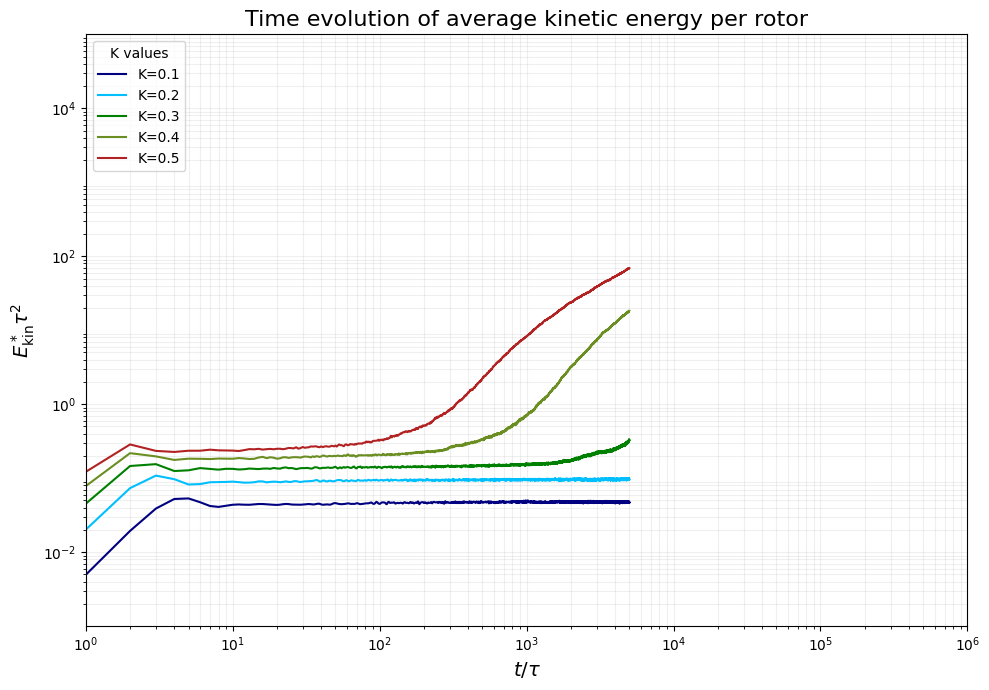

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50
tau = 1.0
timesteps = 5000
samples = 100
K_list = [0.1, 0.2, 0.3, 0.4, 0.5]

# Colors for plotting
def get_color(K):
    return {
        0.1: 'navy',
        0.2: 'deepskyblue',
        0.3: 'green',
        0.4: 'olivedrab',
        0.5: 'firebrick'
    }.get(K, 'black')

# Simulation for one initial condition
def simulate_one(K, N, tau, timesteps):
    kappa = K / tau
    phi = np.random.uniform(0, 2 * np.pi, N)
    p = np.zeros(N)
    E_kin = np.zeros(timesteps + 1)

    for t in range(timesteps + 1):
        E_kin[t] = np.mean(0.5 * p**2)
        if t == timesteps:
            break

        phi_left = np.roll(phi, 1)
        phi_right = np.roll(phi, -1)
        dp = kappa * (np.sin(phi_left - phi) - np.sin(phi - phi_right))
        p += dp
        phi = (phi + p * tau) % (2 * np.pi)

    return E_kin

# Main execution
time_array = np.arange(timesteps + 1) * tau
plt.figure(figsize=(10, 7))
ax = plt.gca()

for K in K_list:
    E_total = np.zeros(timesteps + 1)
    for _ in range(samples):
        E_total += simulate_one(K, N, tau, timesteps)
    E_avg = E_total / samples
    plt.plot(time_array, E_avg, label=f"K={K}", color=get_color(K), linewidth=1.5)

# Axis formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, timesteps)
ax.set_xticks([1, 10, 100, 1000, 10000, 100000, 1000000])
ax.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
ax.set_ylim(1e-3, 1e5)
ax.set_yticks([1e-2, 1e0, 1e2, 1e4])
ax.set_yticklabels(['$10^{-2}$', '$10^0$', '$10^2$', '$10^4$'])

# Labels and final touch
plt.xlabel(r'$t / \tau$', fontsize=14)
plt.ylabel(r'$E_{\mathrm{kin}}^* \tau^2$', fontsize=14)
plt.title("Time evolution of average kinetic energy per rotor", fontsize=16)
plt.legend(title="K values", loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.savefig("fig2_reproduction.png", dpi=300)
plt.show()
